# When Constant Arrays Produce Non-Zero Standard Deviations — Part II

This notebook explains the float32 case from [Part I](01_Floating_point_arithmetic_rounding_error_Part-I.ipynb), where pandas returned a standard deviation of exactly zero for constant arrays while NumPy returned a small non-zero value. <br>

The investigation is done by using pandas' native `nanstd/nanvar` path. Optional Bottleneck acceleration is disabled because it uses a different implementation and can produce different numerical results. Bottleneck behavior is outside the scope of this investigation.

The discussion and outputs are verified with NumPy 2.5.2 and pandas 3.0.5. The implementation details shown below are version-specific because they use pandas internals.

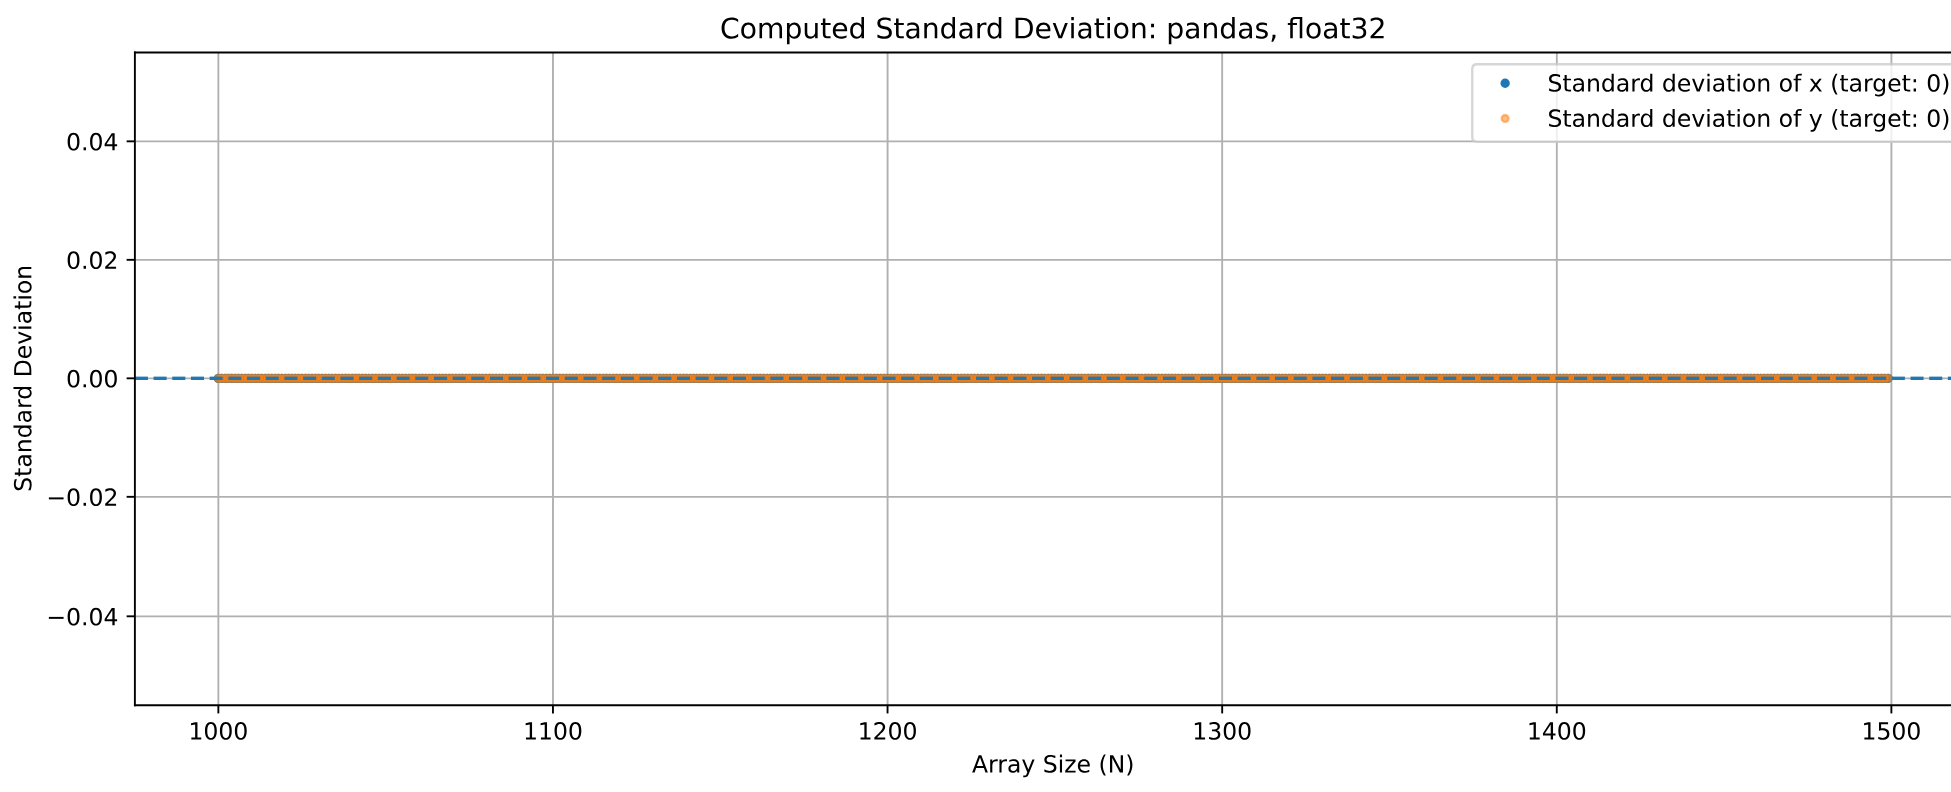
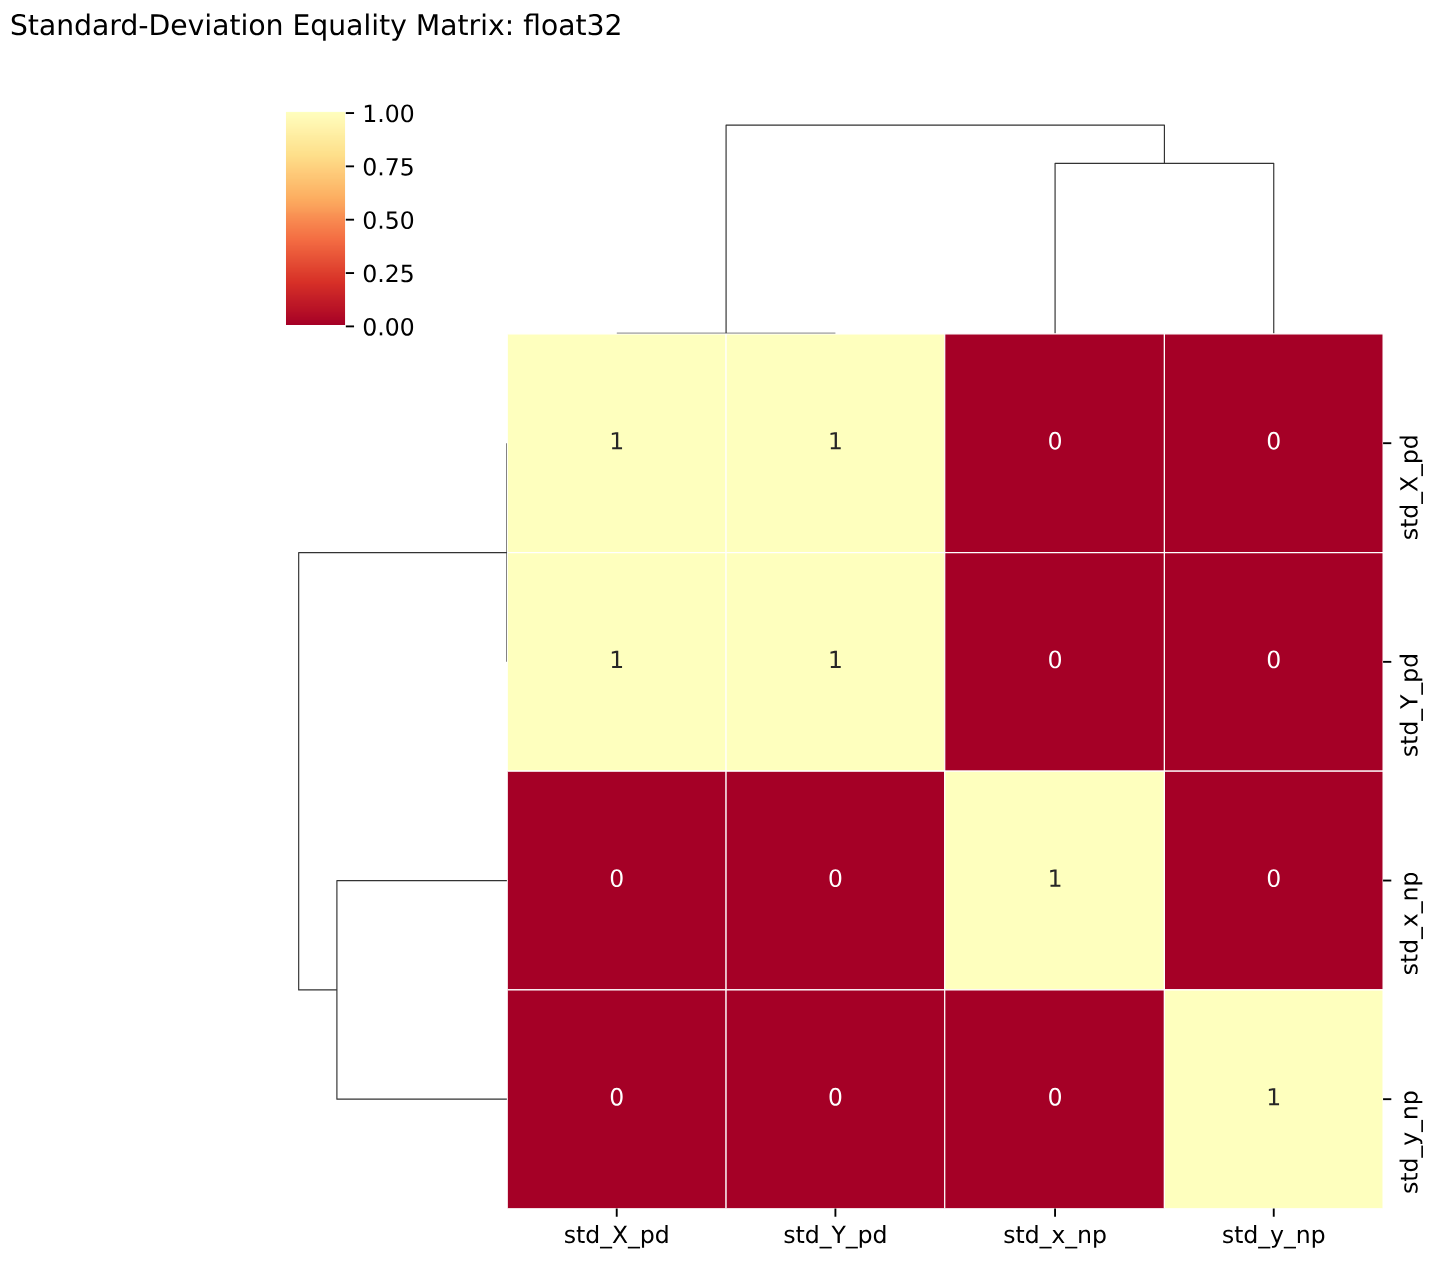

## 1. Reproducing the Part I Observation

In [1]:
import numpy as np
import pandas as pd

pd.set_option("compute.use_bottleneck", False)

print('Numpy version:',np.__version__)
print('Pandas version:',pd.__version__)

Numpy version: 2.5.2
Pandas version: 3.0.5


This sweep extends the Part I range to array sizes from 1,008 through 51,008, in steps of 10.

In [2]:
results = []
for N in range(1_008, 51_009, 10):
    x = np.repeat(np.float32(1.81), N)
    y = np.repeat(np.float32(0.576), N)

    X = pd.Series(x)
    Y = pd.Series(y)

    results.append(
        {
            "N": N,
            "mean_err_x (ULP)": (x.mean() - x[0]) / np.spacing(x[0]),
            "mean_err_y (ULP)": (y.mean() - y[0]) / np.spacing(y[0]),
            "std_x_np": x.std(ddof=1),
            "std_y_np": y.std(ddof=1),
            "std_X_pd": X.std(ddof=1),
            "std_Y_pd": Y.std(ddof=1),
        }
    )

results = pd.DataFrame(results)

In [3]:
results.head()

,N,mean_err_x (ULP),mean_err_y (ULP),std_x_np,std_y_np,std_X_pd,std_Y_pd
0,1008,-4.0,2.0,4.770739e-07,1.192685e-07,0.0,0.0
1,1018,-3.0,1.0,3.578036e-07,5.963394e-08,0.0,0.0
2,1028,-2.0,1.0,2.385346e-07,5.963366e-08,0.0,0.0
3,1038,-3.0,1.0,3.578002e-07,5.963338e-08,0.0,0.0
4,1048,-2.0,2.0,2.385324e-07,1.192662e-07,0.0,0.0


In [4]:
results.describe()

,N,mean_err_x (ULP),mean_err_y (ULP),std_x_np,std_y_np,std_X_pd,std_Y_pd
count,5001.000000,5001.000000,5001.000000,5.001000e+03,5.001000e+03,5001.0,5001.0
mean,26008.000000,-2.618076,1.127774,3.122068e-07,6.758088e-08,0.0,0.0
std,14438.086785,1.004244,0.686346,1.194706e-07,4.031756e-08,0.0,0.0
min,1008.000000,-6.000000,-1.000000,0.000000e+00,0.000000e+00,0.0,0.0
25%,13508.000000,-3.000000,1.000000,2.384222e-07,5.960531e-08,0.0,0.0
50%,26008.000000,-3.000000,1.000000,3.576322e-07,5.960601e-08,0.0,0.0
75%,38508.000000,-2.000000,2.000000,3.576497e-07,1.192105e-07,0.0,0.0
max,51008.000000,1.000000,3.000000,7.152645e-07,1.788626e-07,0.0,0.0


In [5]:
results[["std_X_pd", "std_Y_pd"]].drop_duplicates()

,std_X_pd,std_Y_pd
0,0.0,0.0


For every array size in this sweep, pandas returns a standard deviation of zero for both constant float32 Series.

## 2. Why pandas Returns Zero

In pandas 3.0.5, `Series.std()` uses the `pandas.core.nanops.nanstd()` implementation, which calls `nanvar()` and then takes the square root. This is not equivalent to simply calling `np.std()` on the underlying float32 array.

`nanvar()` implements a two-pass variance calculation. Crucially, it uses float64 accumulators for both sums, even when the input array is float32. Because `pandas.core.nanops` is a private module, this implementation detail may change in a future pandas release.

The essential steps in `nanvar()` are:

```python
average = values.sum(axis=axis, dtype=np.float64) / count
squared_deviations = (average - values) ** 2
variance = squared_deviations.sum(axis=axis, dtype=np.float64) / (count - ddof)
```

The following cells reproduce those operations for the $N = 1448$ float32 example from Part I.

For a sample standard deviation (ddof=1), the variance is computed from residuals around the calculated mean.

$$
s_x = \sqrt{\frac{\sum_{i=0}^{N-1}(x_i - \bar{x})^2}{N - 1}}
$$

Here $\bar{x}$ is the calculated mean and the denominator $N - 1$ corresponds to $\mathrm{ddof}=1$.

If the calculated mean equals every stored value, every squared residual is zero and so is the standard deviation.

Part I showed that a rounded mean can create non-zero deviations even when all stored values are identical. Here we compare a float32 accumulator with the float64 accumulator used by pandas' variance routine.

In [6]:
# The numeric example below mirrors pandas' two-pass calculation without importing private helpers.

In [7]:
x_32 = np.full(1448, 1.810, dtype=np.float32)

In [8]:
print(f"Stored float32 value: {x_32[0]:.40f}")

Stored float32 value: 1.8099999427795410156250000000000000000000


In [9]:
avg_32 = x_32.sum(dtype=np.float32) / x_32.size
avg_64 = x_32.sum(dtype=np.float64) / x_32.size

In [10]:
print(f"Mean with a float32 accumulator: {avg_32:.40f}")
print(f"Mean with a float64 accumulator: {avg_64:.40f}")

Mean with a float32 accumulator: 1.8099995851516723632812500000000000000000
Mean with a float64 accumulator: 1.8099999427795410156250000000000000000000


In [11]:
squared_deviations_32 = (avg_32 - x_32) ** 2
squared_deviations_64 = (avg_64 - x_32) ** 2

var_32 = squared_deviations_32.sum(dtype=np.float32) / (x_32.size - 1)
var_64 = squared_deviations_64.sum(dtype=np.float64) / (x_32.size - 1)

The two means are the critical difference. NumPy's default reduction for a float32 array uses float32 accumulation, while pandas' `nanvar()` uses float64 accumulators for its two sums.

For this array size and value, the float64-accumulated mean equals the stored float32 value exactly:

In [12]:
print(f"Stored value equals float64-accumulated mean: {x_32[0] == avg_64}")

Stored value equals float64-accumulated mean: True


Consequently, every value in `squared_deviations_64` is zero, and the float64-accumulated variance is zero.

In [13]:
np.unique(squared_deviations_64)

array([0.])

Taking the square root produces the corresponding standard deviations:

In [14]:
std_32 = np.sqrt(var_32)
std_64 = np.sqrt(var_64)

print(f"Standard deviation with a float32 accumulator: {std_32!r}")
print(f"Standard deviation with a float64 accumulator: {std_64!r}")

Standard deviation with a float32 accumulator: np.float32(3.5775142e-07)
Standard deviation with a float64 accumulator: np.float64(0.0)


Because the float64-accumulated variance is zero, its standard deviation is zero—the same result returned by pandas `Series.std()` for this float32 example.

For comparison, NumPy's default float32 calculation retains the small non-zero result:

In [15]:
print(f"NumPy std (float32 input): {x_32.std(ddof=1)!r}")

NumPy std (float32 input): np.float32(3.5775142e-07)


The manually reproduced values should match the row for $N = 1448$ in the sweep results.

In [16]:
results.loc[results['N'] == 1448]

,N,mean_err_x (ULP),mean_err_y (ULP),std_x_np,std_y_np,std_X_pd,std_Y_pd
44,1448,-3.0,2.0,3.577514e-07,1.192505e-07,0.0,0.0


In [17]:
row_1448 = results.loc[results["N"].eq(1_448)].iloc[0]
print(f"Float32 calculation matches NumPy: {row_1448['std_x_np'] == std_32}")
print(f"Float64-accumulated calculation matches pandas: {row_1448['std_X_pd'] == std_64}")

Float32 calculation matches NumPy: True
Float64-accumulated calculation matches pandas: True


The comparisons reproduce the Part I observation. NumPy can also return zero when the calculation is explicitly performed with a float64 accumulator for this array.

## 3. Limits of the float64 Accumulator

float32 has a 24-bit significand (23 stored fraction bits plus the implicit leading bit), while float64 has a 53-bit significand.

For the values and array sizes tested so far, the float64 accumulator has sufficient precision for the accumulated mean to equal the stored float32 value. This is not guaranteed for every float32 value or every array size.

To explore much larger array sizes without allocating arrays, the following experiment uses the scalar expression $N \times x / N$. It models the ideal sum of $N$ identical values followed by division, but it does not reproduce the exact reduction algorithms used by NumPy or pandas.

The code scans values of the form $N = 10^{\mathrm{exponent}} + \mathrm{offset}$, using exponents from 3 through 10 and offsets from 0 through 11.

In [18]:
results_scale = []
stored_value = np.float64(np.float32(1.808))

for exponent in range(3, 11):
    for offset in range(12):
        N = 10**exponent + offset
        total = np.float64(N) * stored_value
        mean = total / N

        results_scale.append(
            {
                "N": N,
                "exponent": exponent,
                "offset": offset,
                "mean": mean,
                "mean_error": mean - stored_value,
                "mean_error (ULP)": (mean - stored_value) / np.spacing(stored_value),
            }
        )

results_scale = pd.DataFrame(results_scale)

In [19]:
results_scale.describe()

,N,exponent,offset,mean,mean_error,mean_error (ULP)
count,9.600000e+01,96.000000,96.000000,9.600000e+01,9.600000e+01,96.000000
mean,1.388889e+09,6.500000,5.500000,1.808000e+00,-6.938894e-18,-0.031250
std,3.287834e+09,2.303316,3.470174,7.555701e-17,7.523435e-17,0.338825
min,1.000000e+03,3.000000,0.000000,1.808000e+00,-2.220446e-16,-1.000000
25%,7.750275e+04,4.750000,2.750000,1.808000e+00,0.000000e+00,0.000000
50%,5.500006e+06,6.500000,5.500000,1.808000e+00,0.000000e+00,0.000000
75%,3.250000e+08,8.250000,8.250000,1.808000e+00,0.000000e+00,0.000000
max,1.000000e+10,10.000000,11.000000,1.808000e+00,2.220446e-16,1.000000


In [20]:
idx = results_scale[["mean_error (ULP)"]].drop_duplicates().index

In [21]:
results_scale.loc[idx]

,N,exponent,offset,mean,mean_error,mean_error (ULP)
0,1000,3,0,1.808,0.000000e+00,0.0
73,1000000001,9,1,1.808,2.220446e-16,1.0
75,1000000003,9,3,1.808,-2.220446e-16,-1.0


Among the sampled $N$ values in this scalar model, the first non-zero mean errors appear near $N = 10^9$, even though the multiplication and division use float64.

In [22]:
results_scale.groupby(["exponent", "mean_error (ULP)"]).size().reset_index(name="count")

,exponent,mean_error (ULP),count
0,3,0.0,12
1,4,0.0,12
2,5,0.0,12
3,6,0.0,12
4,7,0.0,12
5,8,0.0,12
6,9,-1.0,3
7,9,0.0,6
8,9,1.0,3
9,10,-1.0,4


The table above counts each ULP error by exponent.

## 4. Conclusion

For the constant float32 arrays studied here, the native pandas 3.0.5 path returns zero because its two-pass variance routine uses float64 accumulators. NumPy's default float32 reduction can round the mean away from the stored value, producing a small non-zero standard deviation. The float64 result is more accurate for these inputs, but finite precision still imposes limits at sufficiently large scales.